In [1]:
import os
import sys
sys.path.insert(1, '../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import utils
import warnings; warnings.simplefilter('ignore')
import time
import scipy
from scipy.stats import norm, bernoulli, uniform
from scipy.special import expit, logit
import xgboost as xgb
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cvxpy as cp
col = [sns.color_palette("pastel")[1], sns.color_palette("pastel")[2], sns.color_palette("pastel")[0],sns.color_palette("pastel")[3]]
sns.set_theme(font_scale=1.5, style='white', palette=col, rc={'lines.linewidth': 3})

In [2]:
def data_generator(n=1000,true_effect=3.0):
    """
    Generate synthetic data for treatment effect estimation.
    """
    
    # Generate covariates/features (X)
    X = np.random.normal(0,1,size=(n, 5))  # 5 features
    
    # Generate treatment binary assignment (Z)
    prob = expit(X[:,2] + X[:,3]+0.5)
    Z = np.random.binomial(1, prob, size=n)
    
    
    sigma2_X_Y0 = np.maximum(3.5 + 0.3 * X[:, 0],0)  # Ensure non-negativity
    sigma2_X_Y1 = np.maximum(1.3 + 0.4 * X[:, 0],0)
    
    # Other versions of heteroskedasticity that we experimented with:
    #sigma2_X_Y0 = 1
    #sigma2_X_Y1 = 1

    #sigma2_X_Y0 = 1 + 1.2*np.sin(2*X[:,0]) + (X[:,0] + X[:,0]**2)/2 
    #sigma2_X_Y1 = 2 + 0.8*np.cos(X[:,2]/2) + X[:,2]**2/5
    
    # Generate potential outcomes
    Y0 = 5 + X[:, 0] - 2 * X[:, 1] + np.random.normal(0,  np.sqrt(sigma2_X_Y0), size=n)  # Baseline (untreated) outcome
    Y1 = Y0 + true_effect + np.random.normal(0, np.sqrt(sigma2_X_Y1), size=n)  # Treated outcome
    
    # Observed outcome (Y) based on treatment
    Y = Z * Y1 + (1 - Z) * Y0 
    
    
    # Create a DataFrame for easy manipulation
    data = pd.DataFrame({
        'X1': X[:, 0],
        'X2': X[:, 1],
        'X3': X[:, 2],
        'X4': X[:, 3],
        'X5': X[:, 4],
        'Z': Z,
        'Y': Y,
        'Y0': Y0,
        'Y1': Y1
    })
    return data

In [3]:
np.random.seed(102)
n = 1000
data = data_generator(n=n)

In [13]:
train_set, validation_set = train_test_split(data, test_size=0.45, stratify=data['Z'], random_state=np.random.randint(100))

In [5]:
true_effect = data['Y1'].mean() - data['Y0'].mean()
print(true_effect)

3.037042297307603


In [6]:
true_effect = train_set['Y1'].mean() - train_set['Y0'].mean()
print(true_effect)

3.045362640595364


In [7]:
true_effect = validation_set['Y1'].mean() - validation_set['Y0'].mean()
print(true_effect)

3.021590231201759


### IPW Estimator on validation set

In [8]:
treatment = 'Z'
y_obs = 'Y'
features = ['X1','X2','X3','X4','X5']
# IPW 
mu1 = np.zeros(validation_set.loc[validation_set[treatment]==1].shape[0])
mu0 = np.zeros(validation_set.loc[validation_set[treatment]==0].shape[0])
model_e1 = utils.fit_prop_score(X=validation_set[features], Z=validation_set[treatment]) 
e1_x = np.clip(model_e1.predict_proba(validation_set[features])[:,0],0.01,0.99)
aipw_est,var_aipw = utils.aipw_estimator(Z=validation_set[treatment].to_numpy(), R=np.ones(validation_set.shape[0]), Y=validation_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(validation_set.shape[0]))
print(aipw_est,var_aipw)

24.615784909597707 7.118792723660274


### AIPW Estimator on validation set

In [14]:
# AIPW (estimating with LR)
_, mu1 = utils.train_mu(Y=validation_set.loc[validation_set[treatment]==1,y_obs], X=validation_set.loc[validation_set[treatment]==1,features],method_mu="estimate")
_, mu0 = utils.train_mu(Y=validation_set.loc[validation_set[treatment]==0,y_obs], X=validation_set.loc[validation_set[treatment]==0,features],method_mu="estimate") 
model_e1 = utils.fit_prop_score(X=validation_set[features], Z=validation_set[treatment]) 
e1_x = np.clip(model_e1.predict_proba(validation_set[features])[:,0],0.01,0.9)
aipw_est,var_aipw = utils.aipw_estimator(Z=validation_set[treatment].to_numpy(), R=np.ones(validation_set.shape[0]), Y=validation_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(validation_set.shape[0]))
print(aipw_est,var_aipw)

3.8004408502763978 0.9138215362390166


In [10]:
true_effect1=aipw_est

In [11]:
num_trials = 100
alpha = 0.05
budgets = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
tune_pi = 0.05

In [15]:
np.random.seed(123456)
results = []
columns = ["pointest","lb", "ub", "interval width","coverage", "estimator","budget"]
temp_df = pd.DataFrame(np.zeros((4,len(columns))), columns=columns)
t1 = time.time()

for j in range(len(budgets)):
    budget = budgets[j]
    print('Budget:',budget)
    
    
 
    for i in range(num_trials):
        if i % 10 == 0: 
            print(i)

        df = data_generator(n=1000)
        train_set, validation_set = train_test_split(df, test_size=0.45,stratify=df[treatment], random_state=np.random.randint(1000))

        # Split train_data into stage 1 and stage 2
        D1, D2 = train_test_split(train_set, test_size=0.45, stratify=train_set[treatment], random_state=np.random.randint(1000))

        Z1 = D1[treatment].to_numpy()
        X1 = D1[features].to_numpy()
        Y1 = D1[y_obs].to_numpy()
        
        Z2 = D2[treatment].to_numpy()
        X2 = D2[features].to_numpy()
        Y2 = D2[y_obs].to_numpy()

        # Batch Adaptive Estimator with Plug-in
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,budget=budget,method_mu='estimate')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,method_mu='estimate')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[0] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-plugin", np.round(budget,2)

        # Batch Adaptive Estimator with Balancing
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,budget=budget,method_mu='estimate',prop_score='balance')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,method_mu='estimate',prop_score='balance')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[1] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-balance", np.round(budget,2)

        # AIPW with random sampling (Baseline)
        R = utils.sampling_r(n=train_set.shape[0],budget = budget)
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.99)
        pi = np.ones(train_set.shape[0])*budget
        _,mu1_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],method_mu="estimate")
        _,mu0_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],method_mu="estimate") 
        pointest_rand, pointest_rand_var = utils.aipw_estimator(Z=train_set[treatment], R=R, Y=train_set[y_obs], mu1=mu1_refit, mu0=mu0_refit, e1_x=e1_x, pi=pi)
        width_rand = norm.ppf(1-alpha/2)*np.sqrt(pointest_rand_var)
        coverage_rand = (true_effect1 >= pointest_rand - width_rand)*(true_effect1 <= pointest_rand + width_rand)
        temp_df.loc[2] = pointest_rand, pointest_rand - width_rand, pointest_rand + width_rand, 2*width_rand,coverage_rand, "random", np.round(budget,2)

        # AIPW with full data (no sampling)
        _, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features], method_mu="estimate")
        _, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features], method_mu="estimate") 
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]*R) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
        aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
        width_est = norm.ppf(1-alpha/2)*np.sqrt(var_aipw)
        coverage_full = (true_effect1 >= aipw_est - width_est)*(true_effect1 <= aipw_est + width_est)
        temp_df.loc[3] = aipw_est, aipw_est - width_est, aipw_est + width_est, 2*width_est,coverage_full, "aipw_full", 1.0
        
        results += [temp_df.copy()]

t2 = time.time()
print(t2-t1)
df = pd.concat(results,ignore_index=True)

Budget: 0.1
0
10
20
30
40
50
60
70
80
90
Budget: 0.2
0
10
20
30
40
50
60
70
80
90
Budget: 0.3
0
10
20
30
40
50
60
70
80
90
Budget: 0.4
0
10
20
30
40
50
60
70
80
90
Budget: 0.5
0
10
20
30
40
50
60
70
80
90
Budget: 0.6
0
10
20
30
40
50
60
70
80
90
Budget: 0.7
0
10
20
30
40
50
60
70
80
90
Budget: 0.8
0
10
20
30
40
50
60
70
80
90
Budget: 0.9
0
10
20
30
40
50
60
70
80
90
6434.176635026932


In [16]:
df["MSE"] = (df["pointest"] - true_effect1) ** 2
df['interval width'] = (df['ub'] - df['pointest'])*2
df['log interval width'] = np.log(df['interval width'])

In [17]:
# Uncomment to save results
# df.to_csv('data/simulated_balancing_results.csv', index=False)

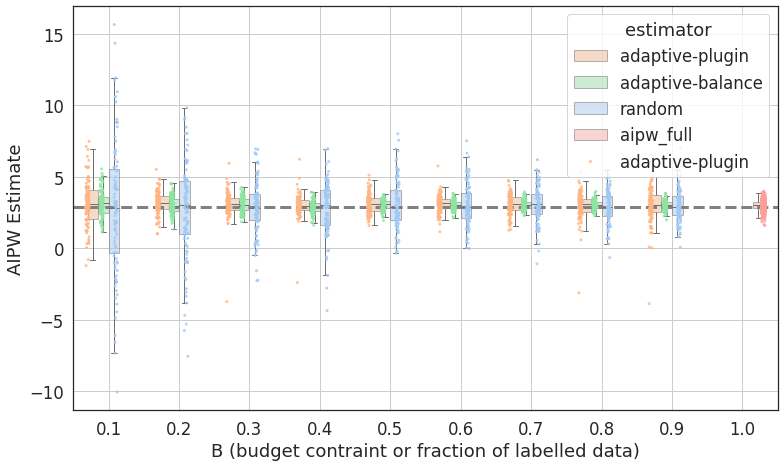

In [18]:
plt.figure(figsize=(11, 6.6))

# Boxplots
sns.boxplot(
    x="budget",
    y="pointest",
    hue="estimator",
    data=df,
    width=0.6,
    dodge=True,
    #palette="Set2",
    showfliers=False,
    boxprops={"alpha": 0.5},  # Set transparency
)

# Overlay points
sns.stripplot(
    x="budget",
    y="pointest",
    hue="estimator",
    data=df,
    dodge=True,
    size=3,
    alpha=0.8,
    #palette=palette
    linewidth=0,
)

# Add true ATE line
plt.axhline(true_effect1, color="grey", linestyle="--", label="True ATE")
#plt.axhline(aipw_est, color="green", linestyle="--", label="AIPW ATE (Oracle)")

# Customize the plot
#plt.title("Comparison of ATE Estimators")
plt.xlabel("B (budget contraint or fraction of labelled data)")
plt.ylabel("AIPW Estimate")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:5], labels[:5], 
    title="estimator", loc='upper right'
)
plt.tight_layout()
plt.grid(True)
#plt.savefig("simulatedexp_boxplots.pdf", bbox_inches="tight")
plt.show()

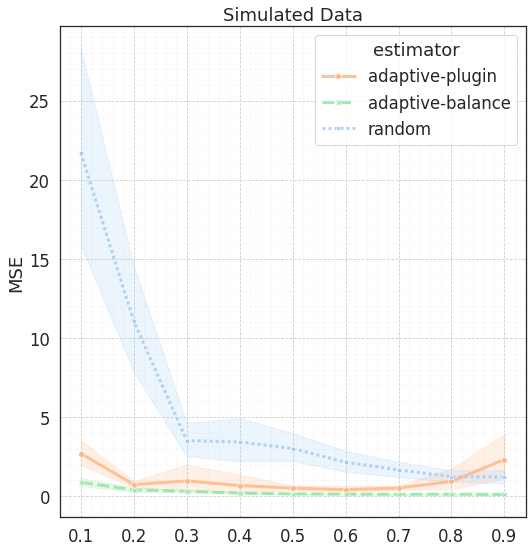

In [19]:

plt.figure(figsize=(7.5, 7.5))
sns.lineplot(data=df[df["budget"]<0.99], x='budget', y='MSE', hue='estimator',  style="estimator",  markers=True, dashes=True, alpha=0.8)
plt.ylabel("MSE")
plt.xlabel(None)
# set x‐ticks at each budget value
budgets = sorted(df[df["budget"] < 0.99]["budget"].unique())
plt.xticks(budgets)
plt.minorticks_on()
plt.grid(which="major", linestyle="--", linewidth=0.8)
plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.title('Simulated Data')
#plt.savefig('balancing_mse_plot.pdf')
plt.show()

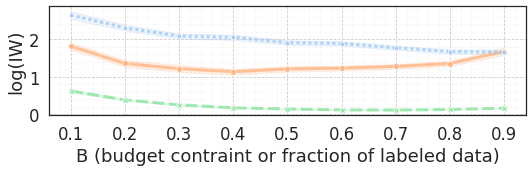

In [20]:
plt.figure(figsize=(7.5, 2.5))
sns.lineplot(data=df[df["budget"]<0.99], x='budget', y='log interval width', hue='estimator', style="estimator",  markers=True, dashes=True, alpha=0.8,legend=False)
plt.ylabel("log(IW)")
plt.xlabel("B (budget contraint or fraction of labeled data)")
budgets = sorted(df[df["budget"] < 0.99]["budget"].unique())
plt.xticks(budgets)
plt.minorticks_on()
plt.grid(which="major", linestyle="--", linewidth=0.8)
plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
#plt.get_legend.remove()
plt.tight_layout()
#plt.savefig('balancing_logiw_plot.pdf')
plt.show()

In [23]:
def make_budget_plot(df, plot_title,filename=None): 
    baseline = "random"
    plugin   = "adaptive-plugin"
    balance  = "adaptive-balance"

    # sorted budgets
    budgets = np.sort(df["budget"].unique())

    # compute mean CI‐widths for each estimator at each budget
    mean_width = {
        est: df[df.estimator == est]
                .groupby("budget")["interval width"]
                .mean()
                .reindex(budgets)      # ensure alignment
                .values
        for est in (baseline, plugin, balance)
    }

    def compute_savings(width_alt, width_base, budgets):
        """ 
        width_alt: 1d array of mean widths for the alt estimator
        width_base: 1d array of mean widths for the random baseline
        budgets:     1d array of sorted budgets
        """
        ns, saves = [], []
        n_budgets = len(budgets)
        
        for n, w_alt in zip(budgets, width_alt):
            # find which two indices to use
            if w_alt > width_base[0]:
                # target is wider than baseline@min_budget --> extrapolate backwards
                j0, j1 = 0, 1
            elif w_alt < width_base[-1]:
                # target is narrower than baseline@max_budget --> extrapolate forwards
                j0, j1 = n_budgets - 2, n_budgets - 1
            else:
                # normal interpolation
                idxs = np.where(width_base >= w_alt)[0]
                j0 = idxs[-1]
                j1 = j0 + 1
            
            # grab budgets and widths at those two points
            b0, b1 = budgets[j0], budgets[j1]
            w0, w1 = width_base[j0], width_base[j1]
            
            # linear interpolate/extrapolate to find baseline budget that hits w_alt
            baseline_n = b0 + (w_alt - w0) / (w1 - w0) * (b1 - b0)
            
            # compute % saved
            save_pct = (baseline_n - n) / baseline_n * 100
            ns.append(n)
            saves.append(save_pct)
        
        return np.array(ns), np.array(saves)

    ns_plug, save_plug = compute_savings(
        width_alt  = mean_width[plugin],
        width_base = mean_width[baseline],
        budgets    = budgets
    )

    ns_bal, save_bal = compute_savings(
    width_alt  = mean_width[balance],
    width_base = mean_width[baseline],
    budgets    = budgets
    )

    plt.figure(figsize=(6, 4))
    plt.plot(ns_plug, save_plug, marker="o", linestyle="--",
                label="adaptive-plugin")
    plt.plot(ns_bal,  save_bal,  marker="s", linestyle="--",
                label="adaptive-balance")


    plt.ylabel("Budget Saved (%) \n over uniform")
    plt.title(plot_title)
    #plt.ylim(-100, 100)
    plt.yticks([0, 25, 50, 75, 100])
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter("%d%%"))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    if filename is not None: 
        plt.savefig(filename)

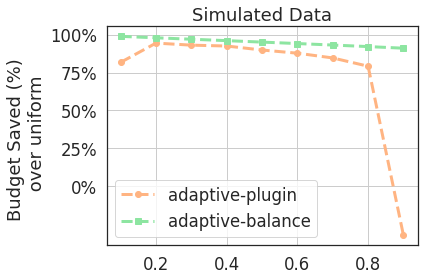

In [24]:
make_budget_plot(df[df['estimator']!='aipw_full'], 'Simulated Data')